# Importando as bibliotecas e os dados

In [2]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import seaborn as sns

import utils.plotting as plotting
import utils.stats as sts

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import ConnectionPatch
from matplotlib.colors import Normalize
plt.rcParams.update({
    "xtick.top": True,
    "ytick.right": True,
    "xtick.direction": "in",
    "font.family": "Lato",
    "ytick.direction": "in",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True
    })

In [3]:
# Importando apenas os dados de estrelas do tipo F
df = pd.read_csv("../data/gcs-Fstars.csv")

## Figuras

### Distribution of the final sample

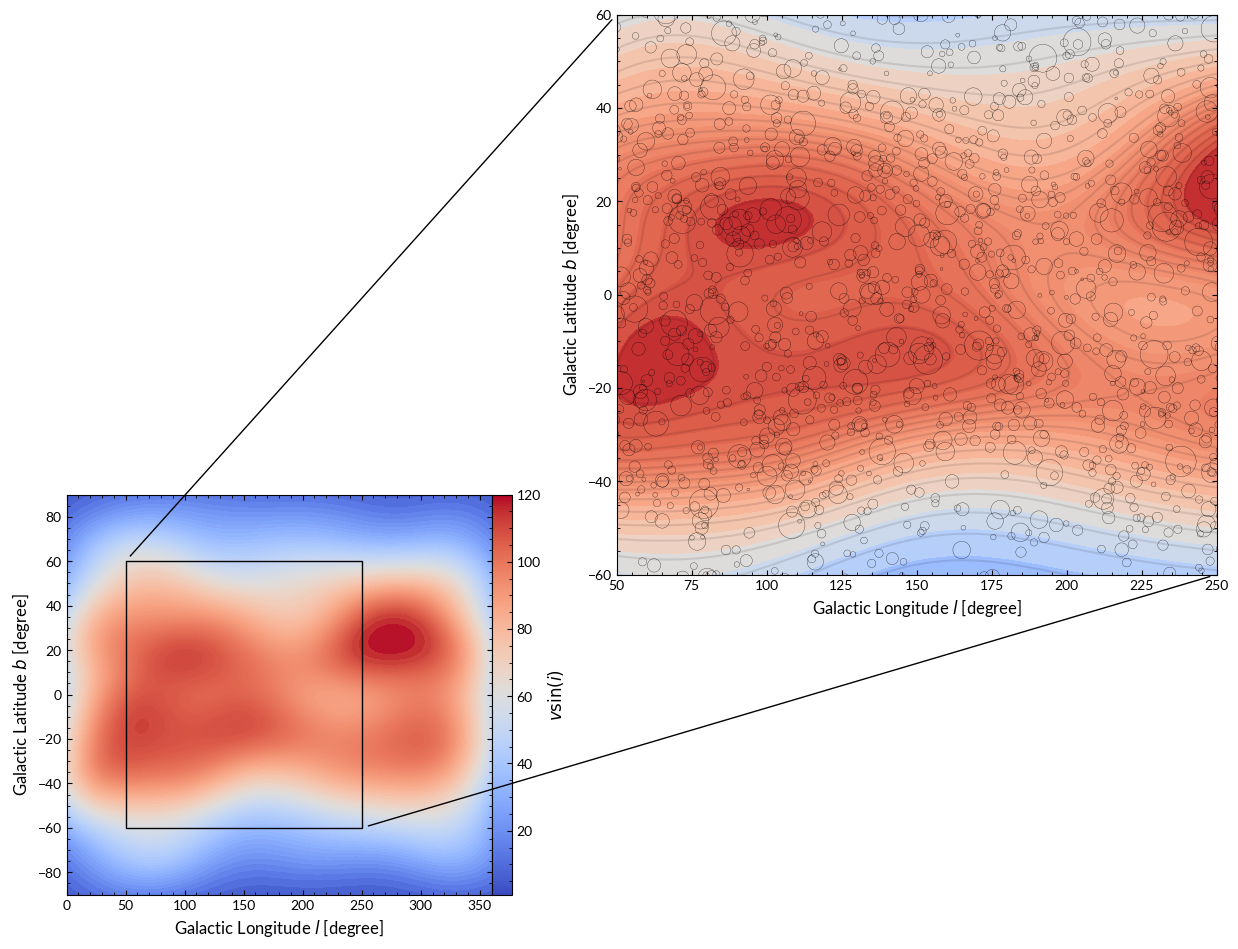

In [244]:
# VERSÃO REIS E CORRADI (2008)
fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_axes([0.05, 0.1, 0.5, 0.5]) 
ax2 = fig.add_axes([0.6, 0.5, 0.6, 0.7])

# Principal
sns_kde1 = sns.kdeplot(
    x=df["GLON"], y=df["GLAT"], weights=df["vsini"], cmap="coolwarm", fill=True,
    thresh=0, levels=100, ax=ax1
)

norm = plt.Normalize(vmin=df["vsini"].min(), vmax=df["vsini"].max())
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax1, orientation='vertical', pad=0)
cbar.set_label(r"$v\sin(i)$")

# Detalhado
sns_kde2 = sns.kdeplot(
    x=df["GLON"], y=df["GLAT"], weights=df["vsini"], cmap="coolwarm", fill=True,
    thresh=0, levels=20, ax=ax2
)
sns.kdeplot(
    x=df["GLON"], y=df["GLAT"], weights=df["vsini"], color="black", levels=20,
    alpha=0.1, ax=ax2
)
ax2.scatter(df["GLON"], df["GLAT"], ec="k", lw=0.2, fc="none", s=df["vsini"] * 4)

ax1.axis([0, 360, -90, 90])
ax2.axis([50, 250, -60, 60])
ax1.set(xlabel="Galactic Longitude $l$ [degree]", ylabel="Galactic Latitude $b$ [degree]")
ax2.set(xlabel="Galactic Longitude $l$ [degree]", ylabel="Galactic Latitude $b$ [degree]")

rect_coords = [(250, -60), (50, 60)]
detail_coords = [(250, -60), (50, 60)]
rect = patches.Rectangle((50, -60), 200, 120, edgecolor='k', facecolor='none')
ax1.add_patch(rect)
for (xyA, xyB) in zip(rect_coords, detail_coords):
    con = ConnectionPatch(
        xyA=xyA, coordsA=ax1.transData,
        xyB=xyB, coordsB=ax2.transData,
        arrowstyle="-", shrinkA=5, shrinkB=5, color="k", lw=1,
    )
    fig.add_artist(con)

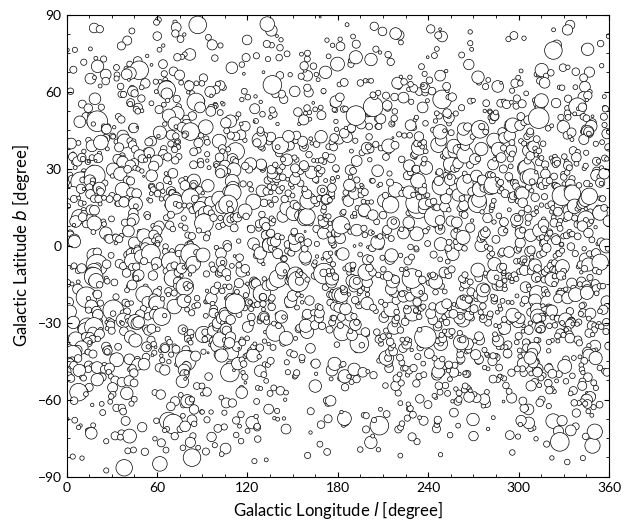

In [4]:
# VERSÃO ANTIGA
_, ax = plt.subplots(figsize=(7,6))

scaler = 2
ax.scatter(df["GLON"], df["GLAT"], s = df["vsini"] * scaler, ec = "k", fc = "white", lw = 0.5)
ax.set(xlim=(0,360), ylim=(-90,90), xlabel="Galactic Longitude $l$ [degree]", ylabel="Galactic Latitude $b$ [degree]")
ax.set_yticks(range(-90,91,30))
ax.set_xticks(range(0,361,60));

### Star number distributed along a 300 × 300 pc2 area (each area defined by a square 30 × 30 pc2)

O gráfico anterior como mostrava, tinha um erro. O cosseno e seno que aparece na função para encontrar $X$, $Y$ e $Z$, **precisa** que a sua entrada seja em radianos, caso contrário, encontra o valor estranho. Assim, ao considerarar o correto, ele retorna o gráfico abaixo.

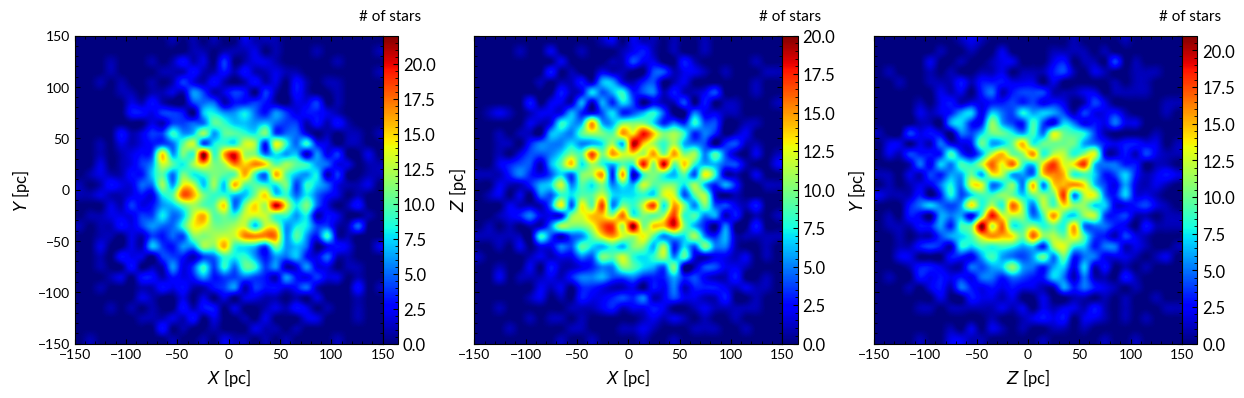

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# A função plot_hist cria um histograma 2D interpolado no conjunto de eixos fornecidos
plotting.plot_hist(ax1, df["X"].values, df["Y"].values, 30, "spline16", "$X$ [pc]", "$Y$ [pc]", "jet", fig)
plotting.plot_hist(ax2, df["X"].values, df["Z"].values, 30, "spline16", "$X$ [pc]", "$Z$ [pc]", "jet", fig)
plotting.plot_hist(ax3, df["Z"].values, df["Y"].values, 30, "spline16", "$Z$ [pc]", "$Y$ [pc]", "jet", fig)

plt.subplots_adjust(wspace=0.1)
plt.show()

### Absolute magnitude

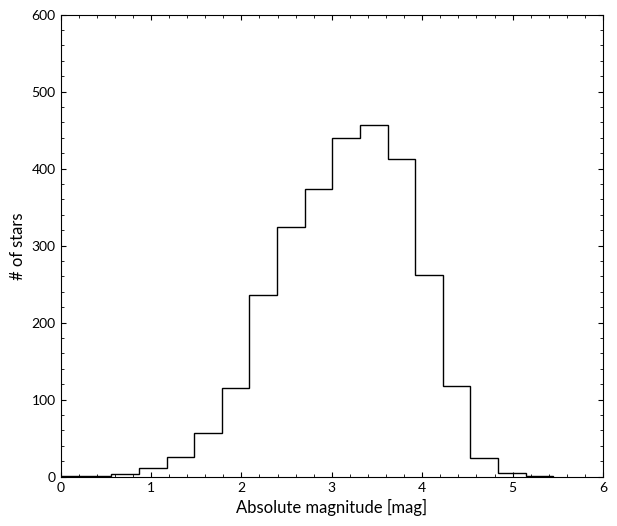

In [7]:
_, ax = plt.subplots(figsize = (7, 6))

ax.hist(df["VMag"], bins = 20, ec = "k", histtype="step")
ax.set(xlabel="Absolute magnitude [mag]", ylabel="# of stars")
plt.axis([0, 6, 0, 600]);

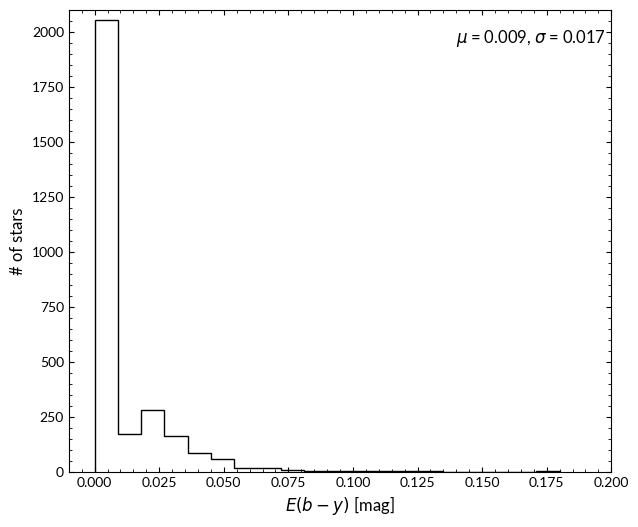

In [229]:
_, ax = plt.subplots(figsize = (7, 6))

media_ebv = df["E(B-V)"].mean()
desvio_padrao_ebv = df["E(B-V)"].std()
text = f'$\mu$ = {media_ebv:.3f}, $\sigma$ = {desvio_padrao_ebv:.3f}'

ax.hist(df["E(B-V)"], bins = 20, ec = "k", histtype="step")
ax.set(xlabel="$E(b-y)$ [mag]", ylabel="# of stars")

ax.text(0.14, 1950, text, fontsize=12)
plt.axis([-0.01, 0.2, 0, 2100]);

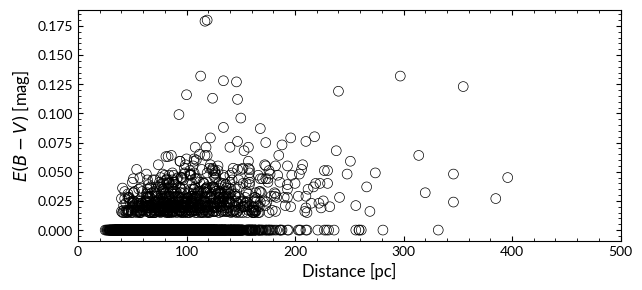

In [253]:
_, ax = plt.subplots(figsize = (7, 3))
ax.scatter(df["Dist"], df["E(B-V)"], ec = "k", fc = "None", lw = 0.5, s = 50)
ax.set(xlabel="Distance [pc]", ylabel="$E(B-V)$ [mag]", xlim=(0, 500));

###  projected velocity v sin i vs. distance R (pc)

Calculate a linear least-squares regression for two sets of measurements.
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html

In [8]:
# Sample 0-80 pc for F
x1 = df[df["Dist"] < 80]["Dist"].values
y1 = df[df["Dist"] < 80]["vsini"].values
s1, i1, e1 = sts.linear_regression(x1,y1)

# Sample 80-350 pc  for F
x2 = df[df["Dist"] > 80]["Dist"].values
y2 = df[df["Dist"] > 80]["vsini"].values
s2, i2, e2 = sts.linear_regression(x2,y2)

print(f"0-80 slope F-stars slope (95%): {s1:.3f} +/- {e1:.3f}")
print(f"80-350 slope F-stars slope (95%): {s2:.3f} +/- {e2:.3f}")

0-80 slope F-stars slope (95%): 0.127 +/- 0.046
80-350 slope F-stars slope (95%): 0.109 +/- 0.025


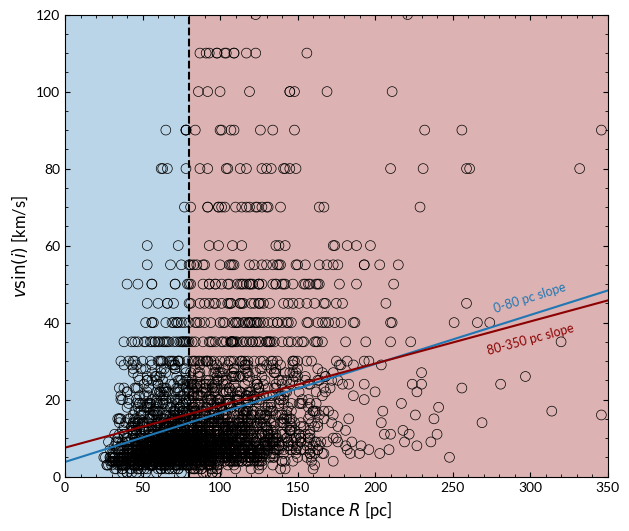

In [9]:
X = np.linspace(0, 400, 100)

_, ax = plt.subplots(figsize=(7,6), sharex=True)

# Sombreamento das regiões antes e depois de x=80
ax.axvspan(0, 80, facecolor="tab:blue", alpha=0.3) 
ax.axvspan(80, 350, facecolor="darkred", alpha=0.3)
ax.axvline(x=80, ls="--", color="k")

# Scatter plots para F e G
ax.scatter(df["Dist"], df["vsini"], ec = "k", fc = "None", lw = 0.5, s = 50)
ax.set_ylim(0, 120)
ax.set_xlim(0, 350)

# Linhas de tendência para F
line1, = ax.plot(X, i1 + s1 * X, "tab:blue", lw=1.5, label="0-80 pc slope")
line2, = ax.plot(X, i2 + s2 * X, "darkred", lw=1.5, label="80-350 pc slope")

plt.ylabel(r"$v \sin(i)$ [km/s]")
plt.xlabel(r"Distance $R$ [pc]")

# Rotulando as linhas
plotting.labelLine(line1, x = 300, fontsize=9, color = "tab:blue", backgroundcolor = "None", verticalalignment = "bottom")
plotting.labelLine(line2, x = 300, fontsize=9, color = "darkred", backgroundcolor = "None", verticalalignment = "top")

### Testes

In [9]:
# Definindo os parâmetros iniciais a partir de um DataFrame df que contém as colunas "X", "Y" e "vsini"
x, y, vsini = df["X"].values, df["Y"].values, df["vsini"].values

# Parâmetros fixos para análise
tc = 20     # Tamanho do quadrado (20 x 20) em pc
B = 1000    # Número de reamostragens (bootstrap)
ul = 150    # Valor para cobrir a área de lado 300 pc

# Intervalo para construir o espaço de análise
interval = 1
ttx = np.arange(-ul, ul + interval * tc, interval * tc)
tty = np.arange(-ul, ul + interval * tc, interval * tc)

# Número de intervalos ao longo de x e y
Nx = len(ttx) - 1
Ny = len(tty) - 1

# Percentual de corte para a média truncada
trimpct = 20

# Processamento principal dos dados
meanoriginal, boot_mean, boot_se, ci1, ci2, largura, shape, countfXY, sigma_distance = sts.process_data(ttx, tty, x, y, vsini, B, trimpct)

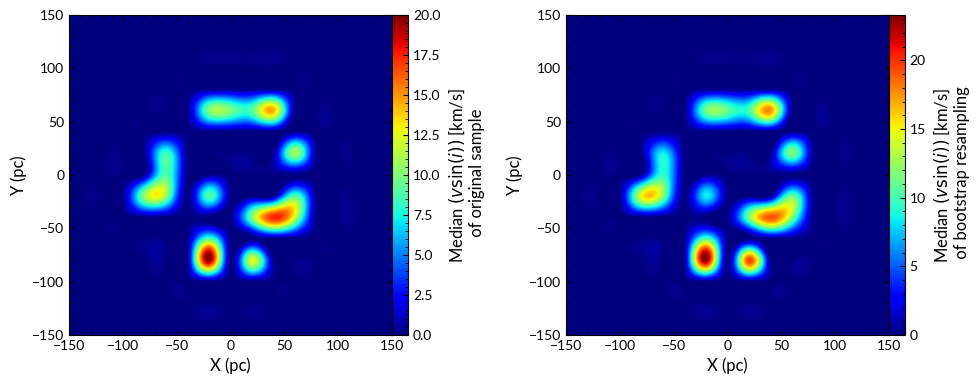

In [10]:
# Considerando que sigma_distance < 1 seja nosso critério
mask = sigma_distance < 1

# Plotagem dos resultados usando a máscara para filtrar dados
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
plots = [(meanoriginal * mask, 'Median $(v \sin(i))$ [km/s] \n of original sample'),
         (boot_mean * mask, 'Median $(v \sin(i))$ [km/s] \n of bootstrap resampling')]

# Loop para plotar cada resultado
for ax, (data, label) in zip(axs.flat, plots):
    method = 'spline36'  # Método de interpolação para o gráfico
    im = ax.imshow(data, aspect='auto', cmap='jet', norm=Normalize(vmin=0), 
                   interpolation=method, extent=(-ul, ul, -ul, ul))
    ax.set_xlabel('X (pc)')
    ax.set_ylabel('Y (pc)')
    cbar = plt.colorbar(im, ax=ax, pad=0)
    cbar.set_label(label)
    
fig.tight_layout()
plt.show()


$$\text{Distância em Sigma} = \frac{|\text{Mediana Observada} - \text{Mediana Bootstrap}|}{\text{Desvio Padrão do Bootstrap}}$$
 

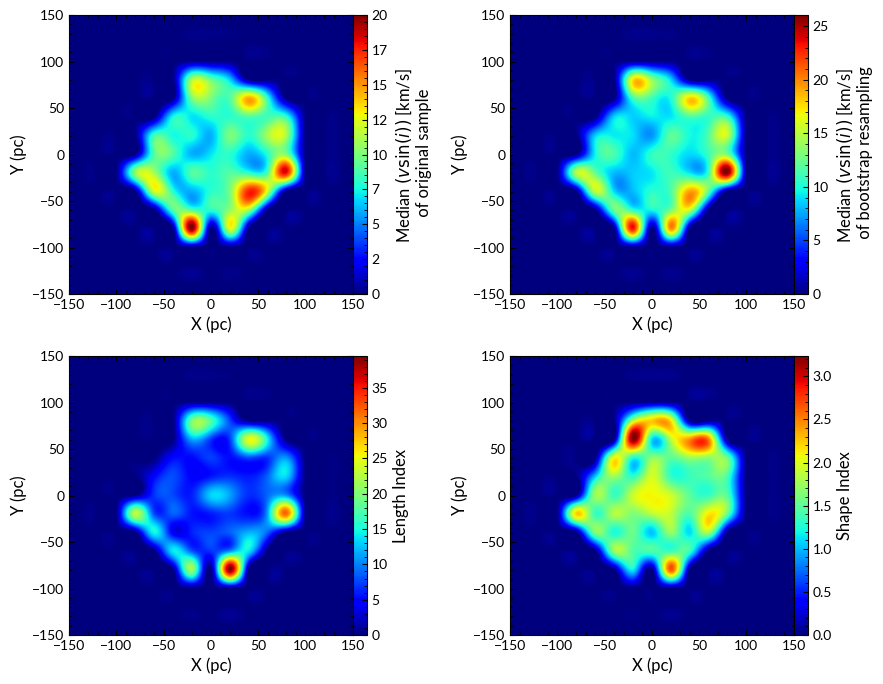

In [11]:
# Plotagem dos resultados
fig, axs = plt.subplots(2, 2, figsize=(9, 7))
plots = [(meanoriginal, 'Median $(v \sin(i))$ [km/s] \n of original sample'),
         (boot_mean, 'Median $(v \sin(i))$ [km/s] \n of bootstrap resampling'),
         (largura, 'Length Index'),
         (shape, 'Shape Index')]

# Loop para plotar cada resultado
for ax, (data, label) in zip(axs.flat, plots):
    niter = 1
    method = 'spline36'  # Método de interpolação para o gráfico
    im = ax.imshow(data, aspect='auto', cmap='jet', norm=Normalize(vmin=0), 
                   interpolation=method, extent=(-ul, ul, -ul, ul))
    ax.set_xlabel('X (pc)')
    ax.set_ylabel('Y (pc)')
    cbar = plt.colorbar(im, ax=ax, pad=0)
    
    if ax == axs[0, 0]:
        cbar.set_label(label)
        cbar.formatter = plt.FuncFormatter(lambda x, _: f'{int(x):d}')
        cbar.update_ticks()
    else:
        cbar.set_label(label)

# Ajusta o layout e mostra o gráfico
fig.tight_layout()
plt.show()

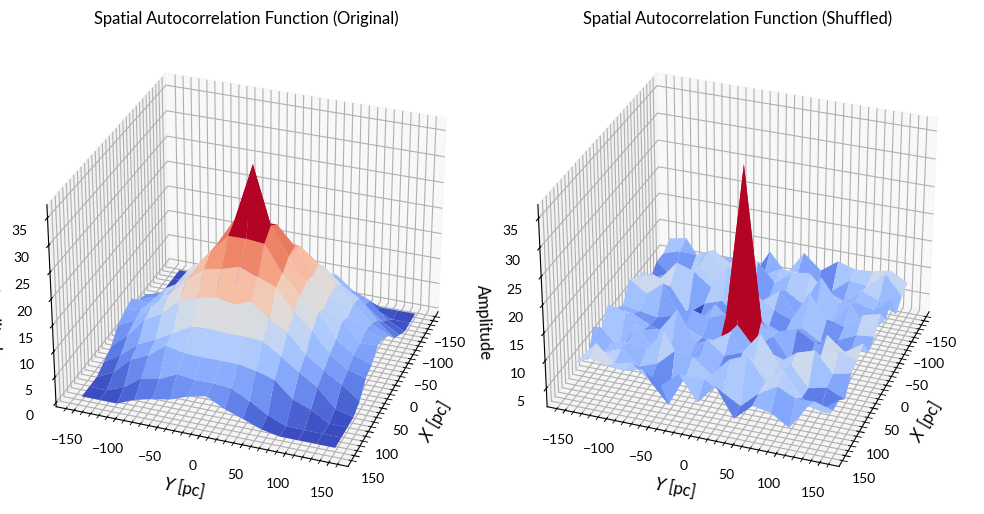

In [12]:
# Data and parameters
X = boot_mean
block_size = 1

# Calculate autocorrelation
B_boot_mean = sts.calculate_autocorrelation_2d(X)
B_scramble = sts.calculate_autocorrelation_2d(sts.scramble_blocks(X, block_size))

# Generate meshgrid for plotting
x = np.linspace(-150, 150, B_boot_mean.shape[1])
y = np.linspace(-150, 150, B_boot_mean.shape[0])
X_mesh, Y_mesh = np.meshgrid(x, y)

# Create a figure and subplots
fig = plt.figure(figsize=(10, 7))

# Plot for B_boot_mean
ax1 = fig.add_subplot(121, projection='3d')
plotting.plot_surface(ax1, X_mesh, Y_mesh, B_boot_mean, "$X$ [pc]", "$Y$ [pc]", 'Spatial Autocorrelation Function (Original)')

# Plot for B_scramble
ax2 = fig.add_subplot(122, projection='3d')
plotting.plot_surface(ax2, X_mesh, Y_mesh, B_scramble,"$X$ [pc]", "$Y$ [pc]", 'Spatial Autocorrelation Function (Shuffled)')

plt.tight_layout()
plt.show()

In [19]:
x = df["X"]
y = df["Y"]
velocity = df["vsini"]
vsini = df["VMag"]

# Parâmetros fixos para análise
tc = 20     # Tamanho do quadrado (20 x 20) em pc
B = 1000    # Número de reamostragens (bootstrap)
ul = 150    # Valor para cobrir a área de lado 300 pc

interval = 1
ttx = np.arange(-ul, ul + interval * tc, interval * tc)
tty = np.arange(-ul, ul + interval * tc, interval * tc)

Nx = len(ttx) - 1
Ny = len(tty) - 1

# Initialize matrices
h = np.zeros((Nx, Ny))
p = np.zeros((Nx, Ny))

meanbootstrap = np.zeros((Nx, Ny))
percentile25boot = np.zeros((Nx, Ny))
percentile50boot = np.zeros((Nx, Ny))
percentile75boot = np.zeros((Nx, Ny))

meanoriginal = np.zeros((Nx, Ny))
percentile25 = np.zeros((Nx, Ny))
percentile50 = np.zeros((Nx, Ny))
percentile75 = np.zeros((Nx, Ny))

vmedian = np.zeros((Nx, Ny))
vmedianc = np.zeros((Nx, Ny))

v25 = np.zeros((Nx, Ny))
cc25 = np.zeros((Nx, Ny))

v50 = np.zeros((Nx, Ny))
cc50 = np.zeros((Nx, Ny))

v75 = np.zeros((Nx, Ny))
cc75 = np.zeros((Nx, Ny))

v25b = np.zeros((Nx, Ny))
cc25b = np.zeros((Nx, Ny))

v50b = np.zeros((Nx, Ny))
cc50b = np.zeros((Nx, Ny))

v75b = np.zeros((Nx, Ny))
cc75b = np.zeros((Nx, Ny))

proporc = np.zeros(B)

# Original sample statistics
for j in range(Nx):
    for i in range(Ny):
        condition = (ttx[j] <= x) & (x < ttx[j + 1]) & (tty[i] <= y) & (y < tty[i + 1])
        count = np.sum(condition)
        
        if count >= 20:
            meanoriginal[i, j] = np.median(vsini[condition])
            vmedian[i, j] = np.median(velocity[condition])
            
            sorted_vsini = np.sort(vsini[condition])
            percentile25[i, j] = np.percentile(sorted_vsini, 25)
            percentile50[i, j] = np.percentile(sorted_vsini, 50)
            percentile75[i, j] = np.percentile(sorted_vsini, 75)
            
            cc25 = int(round(count / 4)) if count > 0 else 0
            cc50 = int(round(count / 2)) if count > 0 else 0
            cc75 = int(round(3 * count / 4)) if count > 0 else 0

            if cc25 > 0:
                v25[i, j] = velocity[cc25]
            else:
                v25[i, j] = 0

            if cc50 > 0:
                v50[i, j] = velocity[cc50]
            else:
                v50[i, j] = 0

            if cc75 > 0:
                v75[i, j] = velocity[cc75]
            else:
                v75[i, j] = 0

# Bootstrap resampling
vsini_boot = sts.bootrsp(vsini, B)
for k in range(B):
    vsini = vsini_boot[:, k]

    for j in range(Nx):
        for i in range(Ny):
            condition = (ttx[j] <= x) & (x < ttx[j + 1]) & (tty[i] <= y) & (y < tty[i + 1])
            count = np.sum(condition)
            
            if count >= 20:
                meanbootstrap[i, j] = np.median(vsini[condition])
                vmedianc[i, j] = np.median(velocity[condition])
                
                sorted_vsini = np.sort(vsini[condition])
                percentile25boot[i, j] = np.percentile(sorted_vsini, 25)
                percentile50boot[i, j] = np.percentile(sorted_vsini, 50)
                percentile75boot[i, j] = np.percentile(sorted_vsini, 75)
                
                cc25b = int(round(count / 4)) if count > 0 else 0
                cc50b = int(round(count / 2)) if count > 0 else 0
                cc75b = int(round(3 * count / 4)) if count > 0 else 0

                if cc25b > 0:
                    v25b[i, j] = velocity[cc25b]
                else:
                    v25b[i, j] = 0

                if cc50b > 0:
                    v50b[i, j] = velocity[cc50b]
                else:
                    v50b[i, j] = 0

                if cc75b > 0:
                    v75b[i, j] = velocity[cc75b]
                else:
                    v75b[i, j] = 0

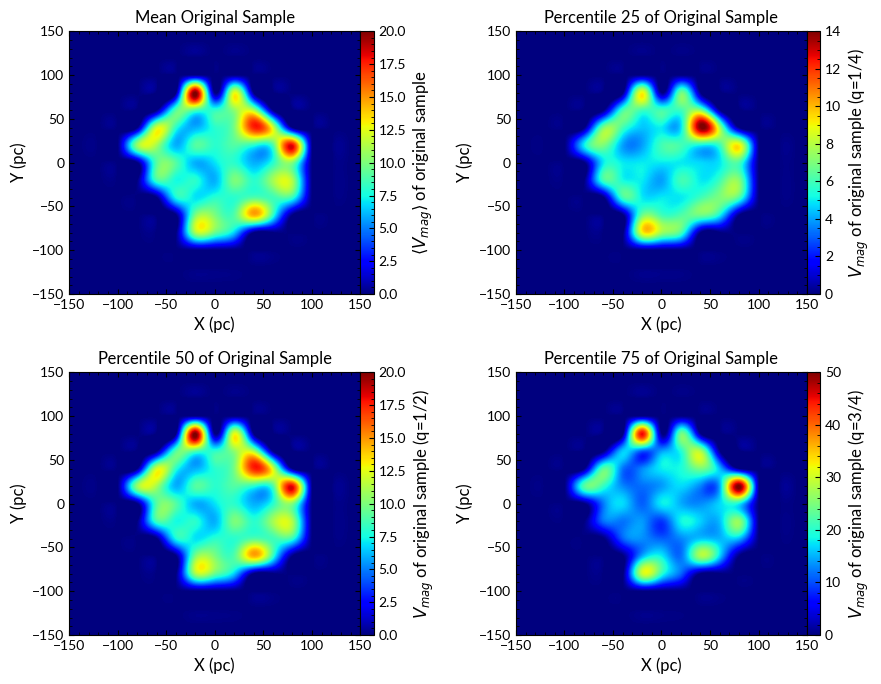

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(9, 7))

# Plot 1: Mean original sample
ax1 = axs[0, 0]
cax1 = ax1.imshow(meanoriginal, aspect='auto', cmap='jet', origin='lower', interpolation = "spline36",  extent=(-ul, ul, -ul, ul))
fig.colorbar(cax1, ax=ax1, label=r'$\langle V_{mag} \rangle$ of original sample', pad=0)
ax1.set_xlabel('X (pc)')
ax1.set_ylabel('Y (pc)')
ax1.set_title('Mean Original Sample')

# Plot 2: Percentile 25 of original sample
ax2 = axs[0, 1]
cax2 = ax2.imshow(percentile25, aspect='auto', cmap='jet', origin='lower', interpolation = "spline36",  extent=(-ul, ul, -ul, ul))
fig.colorbar(cax2, ax=ax2, label=r'$V_{mag}$ of original sample (q=1/4)', pad=0)
ax2.set_xlabel('X (pc)')
ax2.set_ylabel('Y (pc)')
ax2.set_title('Percentile 25 of Original Sample')

# Plot 3: Percentile 50 of original sample
ax3 = axs[1, 0]
cax3 = ax3.imshow(percentile50, aspect='auto', cmap='jet', origin='lower', interpolation = "spline36",  extent=(-ul, ul, -ul, ul))
fig.colorbar(cax3, ax=ax3, label=r'$V_{mag}$ of original sample (q=1/2)', pad=0)
ax3.set_xlabel('X (pc)')
ax3.set_ylabel('Y (pc)')
ax3.set_title('Percentile 50 of Original Sample')

# Plot 4: Percentile 75 of original sample
ax4 = axs[1, 1]
cax4 = ax4.imshow(percentile75, aspect='auto', cmap='jet', origin='lower', interpolation = "spline36",  extent=(-ul, ul, -ul, ul))
fig.colorbar(cax4, ax=ax4, label=r'$V_{mag}$ of original sample (q=3/4)', pad=0)
ax4.set_xlabel('X (pc)')
ax4.set_ylabel('Y (pc)')
ax4.set_title('Percentile 75 of Original Sample')

plt.tight_layout()
plt.show()

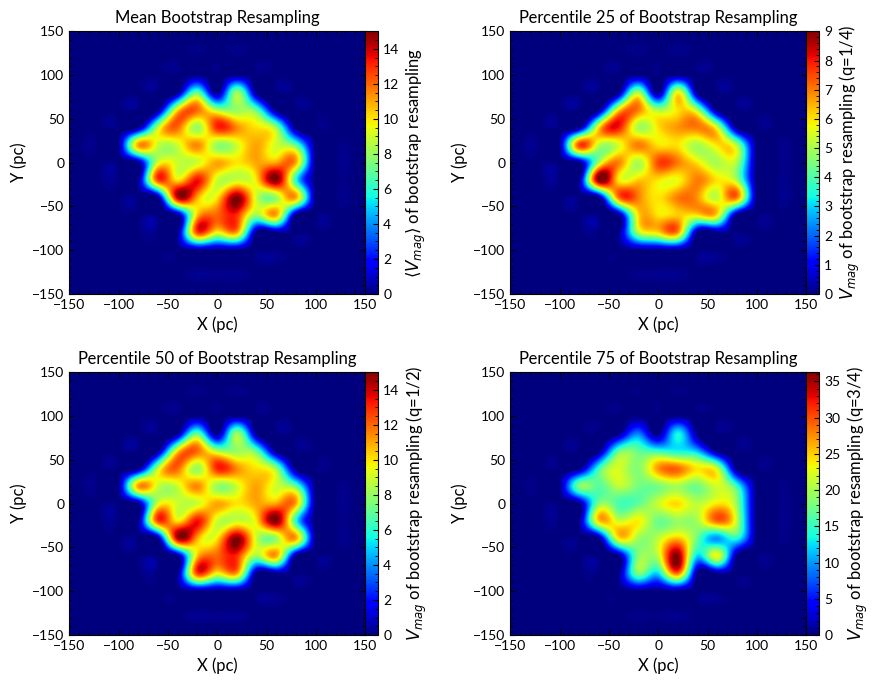

In [21]:
# Create a new figure for the bootstrap resampling results
fig, axs = plt.subplots(2, 2, figsize=(9,7))

# Plot 1: Mean of bootstrap resampling
ax1 = axs[0, 0]
cax1 = ax1.imshow(meanbootstrap, aspect='auto', cmap='jet', origin='lower', interpolation = "spline36",  extent=(-ul, ul, -ul, ul))
fig.colorbar(cax1, ax=ax1, label=r'$\langle V_{mag} \rangle$ of bootstrap resampling', pad=0)
ax1.set_xlabel('X (pc)')
ax1.set_ylabel('Y (pc)')
ax1.set_title('Mean Bootstrap Resampling')

# Plot 2: Percentile 25 of bootstrap resampling
ax2 = axs[0, 1]
cax2 = ax2.imshow(percentile25boot, aspect='auto', cmap='jet', origin='lower', interpolation = "spline36",  extent=(-ul, ul, -ul, ul))
fig.colorbar(cax2, ax=ax2, label=r'$V_{mag}$ of bootstrap resampling (q=1/4)', pad=0)
ax2.set_xlabel('X (pc)')
ax2.set_ylabel('Y (pc)')
ax2.set_title('Percentile 25 of Bootstrap Resampling')

# Plot 3: Percentile 50 of bootstrap resampling
ax3 = axs[1, 0]
cax3 = ax3.imshow(percentile50boot, aspect='auto', cmap='jet', origin='lower', interpolation = "spline36",  extent=(-ul, ul, -ul, ul))
fig.colorbar(cax3, ax=ax3, label=r'$V_{mag}$ of bootstrap resampling (q=1/2)', pad=0)
ax3.set_xlabel('X (pc)')
ax3.set_ylabel('Y (pc)')
ax3.set_title('Percentile 50 of Bootstrap Resampling')

# Plot 4: Percentile 75 of bootstrap resampling
ax4 = axs[1, 1]
cax4 = ax4.imshow(percentile75boot, aspect='auto', cmap='jet', origin='lower', interpolation = "spline36",  extent=(-ul, ul, -ul, ul))
fig.colorbar(cax4, ax=ax4, label=r'$V_{mag}$ of bootstrap resampling (q=3/4)', pad=0)
ax4.set_xlabel('X (pc)')
ax4.set_ylabel('Y (pc)')
ax4.set_title('Percentile 75 of Bootstrap Resampling')

plt.tight_layout()
plt.show()


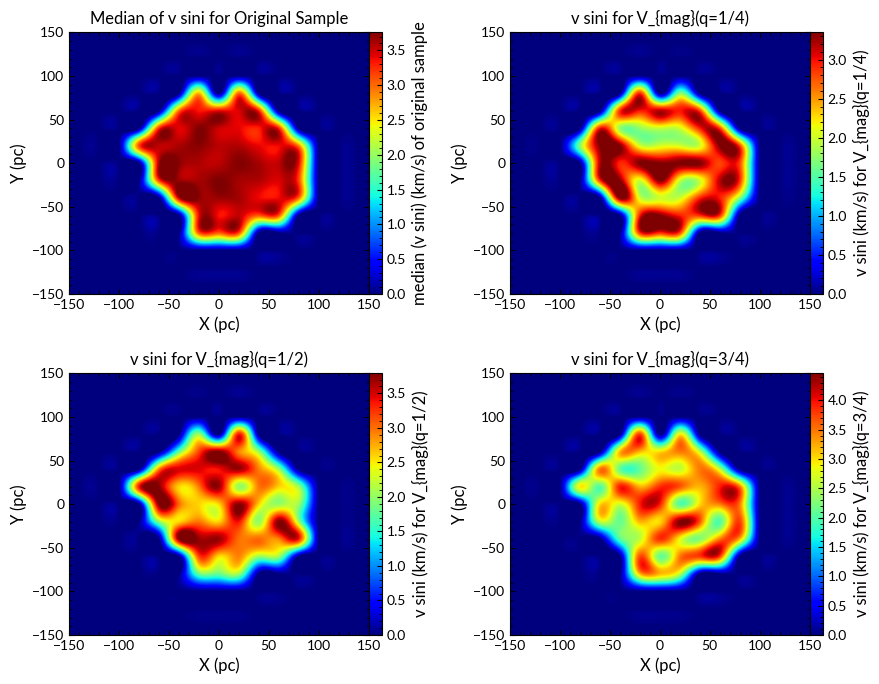

In [22]:
# Create a new figure
fig, axs = plt.subplots(2, 2, figsize=(9,7))

# Plot 1: Median of v sini for the original sample
ax1 = axs[0, 0]
cax1 = ax1.imshow(vmedian, aspect='auto', cmap='jet', origin='lower', interpolation = "spline36",  extent=(-ul, ul, -ul, ul))
fig.colorbar(cax1, ax=ax1, label='median (v sini) (km/s) of original sample', pad=0)
ax1.set_xlabel('X (pc)')
ax1.set_ylabel('Y (pc)')
ax1.set_title('Median of v sini for Original Sample')

# Plot 2: v sini for V_mag (q=1/4)
ax2 = axs[0, 1]
cax2 = ax2.imshow(v25, aspect='auto', cmap='jet', origin='lower', interpolation = "spline36",  extent=(-ul, ul, -ul, ul))
fig.colorbar(cax2, ax=ax2, label='v sini (km/s) for V_{mag}(q=1/4)', pad=0)
ax2.set_xlabel('X (pc)')
ax2.set_ylabel('Y (pc)')
ax2.set_title('v sini for V_{mag}(q=1/4)')

# Plot 3: v sini for V_mag (q=1/2)
ax3 = axs[1, 0]
cax3 = ax3.imshow(v50, aspect='auto', cmap='jet', origin='lower', interpolation = "spline36",  extent=(-ul, ul, -ul, ul))
fig.colorbar(cax3, ax=ax3, label='v sini (km/s) for V_{mag}(q=1/2)', pad=0)
ax3.set_xlabel('X (pc)')
ax3.set_ylabel('Y (pc)')
ax3.set_title('v sini for V_{mag}(q=1/2)')

# Plot 4: v sini for V_mag (q=3/4)
ax4 = axs[1, 1]
cax4 = ax4.imshow(v75, aspect='auto', cmap='jet', origin='lower', interpolation = "spline36",  extent=(-ul, ul, -ul, ul))
fig.colorbar(cax4, ax=ax4, label='v sini (km/s) for V_{mag}(q=3/4)', pad=0)
ax4.set_xlabel('X (pc)')
ax4.set_ylabel('Y (pc)')
ax4.set_title('v sini for V_{mag}(q=3/4)')

plt.tight_layout()
plt.show()


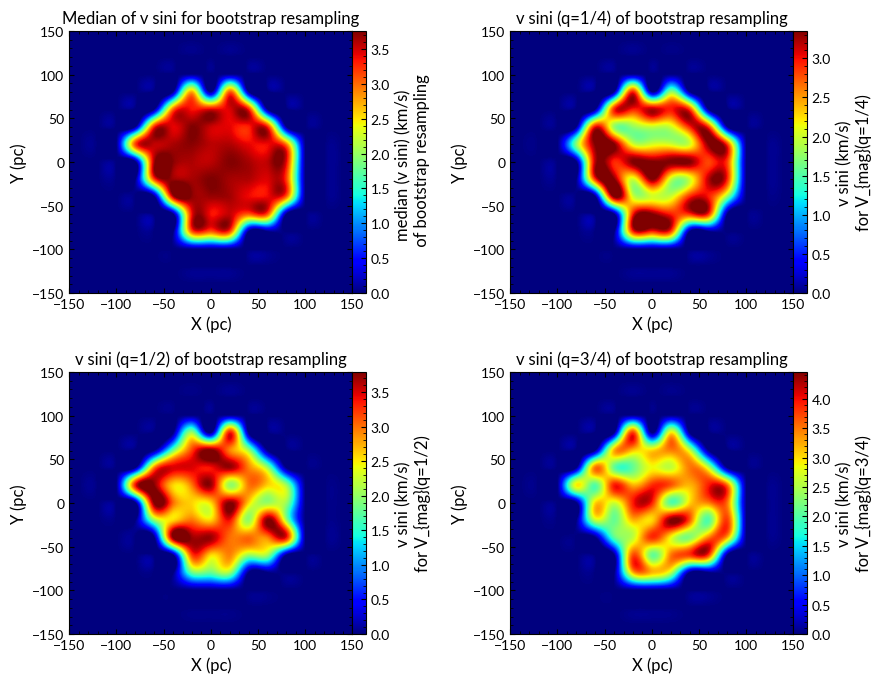

In [23]:
# Figures are the same because is not make the bootstrap of velocity
fig, axs = plt.subplots(2, 2, figsize=(9,7))

# Plot for median (v sini) of bootstrap resampling
ax1 = axs[0, 0]
cax1 = ax1.imshow(vmedianc, aspect='auto', cmap='jet', origin='lower', interpolation = "spline36",  extent=(-ul, ul, -ul, ul))
fig.colorbar(cax1, ax=ax1, label='median (v sini) (km/s) \n of bootstrap resampling', pad=0)
ax1.set_xlabel('X (pc)')
ax1.set_ylabel('Y (pc)')
ax1.set_title('Median of v sini for bootstrap resampling')

# Plot for v sini (q=1/4) of bootstrap resampling
ax2 = axs[0, 1]
cax2 = ax2.imshow(v25b, aspect='auto', cmap='jet', origin='lower', interpolation = "spline36",  extent=(-ul, ul, -ul, ul))
fig.colorbar(cax2, ax=ax2, label='v sini (km/s)\nfor V_{mag}(q=1/4)', pad=0)
ax2.set_xlabel('X (pc)')
ax2.set_ylabel('Y (pc)')
ax2.set_title('v sini (q=1/4) of bootstrap resampling')

# Plot for v sini (q=1/2) of bootstrap resampling
ax3 = axs[1, 0]
cax3 = ax3.imshow(v50b, aspect='auto', cmap='jet', origin='lower', interpolation = "spline36",  extent=(-ul, ul, -ul, ul))
fig.colorbar(cax3, ax=ax3, label='v sini (km/s)\nfor V_{mag}(q=1/2)', pad=0)
ax3.set_xlabel('X (pc)')
ax3.set_ylabel('Y (pc)')
ax3.set_title('v sini (q=1/2) of bootstrap resampling')

# Plot for v sini (q=3/4) of bootstrap resampling
ax4 = axs[1, 1]
cax4 = ax4.imshow(v75b, aspect='auto', cmap='jet', origin='lower', interpolation = "spline36",  extent=(-ul, ul, -ul, ul))
fig.colorbar(cax4, ax=ax4, label='v sini (km/s)\nfor V_{mag}(q=3/4)', pad=0)
ax4.set_xlabel('X (pc)')
ax4.set_ylabel('Y (pc)')
ax4.set_title('v sini (q=3/4) of bootstrap resampling')

plt.tight_layout()
plt.show()